In [1]:
import numpy as np
import matplotlib.pyplot as plt
from doublePlume_V3 import doublePlume as dP
import params as p
import const as c
import gsw
import cmocean.cm as cm
from scipy.interpolate import interp1d
import os

sec_to_day = 60 * 60 * 24
print(plt.rcParams.keys())
plt.rcParams.update({
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'b

In [2]:
salt_file = 'saltini.bin'
temp_file = 'tempini.bin'
dx_file = 'delx.bin'
dy_file = 'dely.bin'

dx = np.fromfile(dx_file, dtype = "<f8")
dy = np.fromfile(dy_file, dtype = "<f8")
dz = np.arange(-500,0,10)

Nx = len(dx)
Ny = len(dy)
Nz = len(dz)

salt = np.fromfile(salt_file, dtype = "<f8")
salt = salt.reshape((Nx, Ny, Nz), order = "F")
temp = np.fromfile(temp_file, dtype = "<f8")
temp = temp.reshape((Nx, Ny, Nz), order = "F")

mp = int(Ny/2)
saltProf = salt[0,mp,1:]
tempProf = temp[0,mp,1:]
zProf = np.linspace(0,490,Nz-1)
PProf = np.zeros(Nz-1)
OProf = np.zeros(Nz-1)

In [3]:
P0 = 101000
# ambient = np.array([[0, 50, 100, 150, 200, 250, 300, 350, 400], #z [m], 0 is at diffuser
#                     [1.8, 1.6, 1.4, 1.2, 1.0, 0.8, 0.6, 0.4, 0.2], # temp [C]
#                    [33, 33, 33, 32, 31, 30, 29, 28, 27], # salinity [psu]
#                    [0, 0, 0, 0, 0, 0, 0, 0, 0],#1082000, 836750, 591500, 346250, 101000], # [Pa] pressure
#                    [0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001], # [?] O2
#                    ])
ambient = np.array([zProf, tempProf[::-1], saltProf[::-1], PProf, OProf])
ambient[3, :] = ambient[0,:] * p.rho_r * c.g + P0
ambient[3, :] = ambient[3, :][::-1]

In [4]:
p.R = 2.5 # [m]
p.C0 = 0.005 # [kg/m^3]
p.S0 = 0.01 # [psu]
p.Qsg = 1 #1e-2 
p.Usg = 11 * 2 * p.Qsg / (np.pi * p.R**2)
print(f"Usg: {p.Usg}")
p.modelType = 'single_plume'
rho_g = ambient[3,0] * c.M_gas[0][0][0] / (c.Ru * c.T0) # [kg/m^3]

jps = np.zeros(10)
cmap = cm.haline(np.linspace(0,1,len(jps)))
i_peels = []
phi = 0.1
Qg = 0.1 * p.Qsg
mb0 = Qg * rho_g # [kg/s]
p.mb0 = mb0
singlePlume = dP(ambient, p)
y, z, yo, zo, jp, i_peel = dP.returnResults(singlePlume)
mdot_sp = singlePlume.melting(y, z, p)
Sb_sp = singlePlume.boundary_salinity(y, mdot_sp, p)
Tb_sp = singlePlume.boundary_temperature(Sb_sp, z, p)

p.modelType = 'double_plume'
doublePlume = dP(ambient, p)
yi, zi, yo, zo, jp, i_peel = dP.returnResults(doublePlume)
mdot_dp = doublePlume.melting(yi, zi, p)
Sb_dp = doublePlume.boundary_salinity(yi, mdot_dp, p)
Tb_dp = doublePlume.boundary_temperature(Sb_dp, zi, p)

Usg: 1.1204507993669433
Q_g = 0.0940890312732867
=== Plume Initial Conditions ===
Qi=1.094 m^3/s, Ji=0.122 m^4/s^2, Hi=1288228902.009 m^3°C/s, Bi=0.011 m^3/s psu, Ci=0.005470 kg/s
ui=0.111 m/s, bi=2.500 m,               Ti=-0.293 °C, Si=0.010 m^3/s psu, Ci=0.005000 kg/m^3
tambient, sambient: 1.12,34.495
No momentum. ui = 0.04890678815832074, mom = 34.30329249766907
No momentum. ui = 0.04890678815832074, mom = 34.30329249766906
Discrete peel 1
 Height: 471.30827943062025 m
Initial conditions for next peel:
Qi: 35.070072876818955, ui: 0.6661671600976018
Initial Conditions for outer plume
Qo, uo, To, So, Co: -62.849673253415254, [0.0439343], 0.46126078282422067, 33.33251514598668, 0.0022217867909712324
z0: 490.0
      - Top outer plume 490.0 - 471.30827943062025
 Initial conditions are: 


/Users/mmamer3/Documents/plume/doublePlume_V3.py:455: RuntimeWarning: invalid value encountered in scalar power
  bo = (2 * yo[0]/(uo * np.pi) + bi**2)**(1/2)                                   # outer radius
/Users/mmamer3/Documents/plume/doublePlume_V3.py:1047: RuntimeWarning: invalid value encountered in sqrt
  bo = (2 * Qo/(np.pi * uo) + bi**2)**(1/2)
/Users/mmamer3/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


outer plume lost momentum, y[1]: 0.0004335823243503286
outer plume lost momentum, y[1]: 0.00043358232435032867
No momentum. ui = 0.04890678815832074, mom = 34.30329249766907
No momentum. ui = 0.04890678815832074, mom = 34.30329249766906
Discrete peel 1
 Height: 471.30827943062025 m
Initial conditions for next peel:
Qi: 35.070072876818955, ui: 0.6661671600976018
Initial Conditions for outer plume
Qo, uo, To, So, Co: -62.849673253415254, [0.0439343], 0.46126078282422067, 33.33251514598668, 0.0022217867909712324
z0: 490.0
      - Top outer plume 490.0 - 471.30827943062025
 Initial conditions are: 
outer plume lost momentum, y[1]: 0.0004335823243503286
outer plume lost momentum, y[1]: 0.00043358232435032867
Percent Error = 0.0


In [5]:
z_sp = np.linspace(-ambient[0,-1], 0, len(y[0]))
zi_dp = np.linspace(-ambient[0,-1], 0, len(yi[0]))
zo_dp = np.linspace(-ambient[0,-1], 0, len(yo[0]))

u = y[1]/y[0]
T = y[2]/y[0]
S = y[3]/y[0]

ui = yi[1]/yi[0]
Ti = yi[2]/(yi[0] * c.cp * p.rho_r) - c.T0
Si = yi[4]/yi[0]
bi = (2 * yi[0]/(ui * np.pi))**(1/2)
uo = yo[1]/yo[0]
uo = uo[::-1]
To = yo[2]/(yo[0] * c.cp * p.rho_r) - c.T0
To = To[::-1]
So = yo[3]/yo[0]
So = So[::-1]

Pa_interp = interp1d(ambient[0,:][::-1], ambient[-2,:])
Pa_i = Pa_interp(-zi_dp)
Pa_o = Pa_interp(-zo_dp)
rho_i = gsw.density.rho_t_exact(Si, Ti, Pa_i/10**4)
rho_o = gsw.density.rho_t_exact(So, To, Pa_o/10**4)
rho_a = gsw.density.rho_t_exact(ambient[2,:], ambient[1,:], ambient[-2,:]/10**4)

/var/folders/b0/25x33fpn6_jcyj0hj0v0_qpw02w58x/T/ipykernel_70416/1126224368.py:13: RuntimeWarning: invalid value encountered in divide
  uo = yo[1]/yo[0]
/var/folders/b0/25x33fpn6_jcyj0hj0v0_qpw02w58x/T/ipykernel_70416/1126224368.py:15: RuntimeWarning: invalid value encountered in divide
  To = yo[2]/(yo[0] * c.cp * p.rho_r) - c.T0
/var/folders/b0/25x33fpn6_jcyj0hj0v0_qpw02w58x/T/ipykernel_70416/1126224368.py:17: RuntimeWarning: invalid value encountered in divide
  So = yo[3]/yo[0]


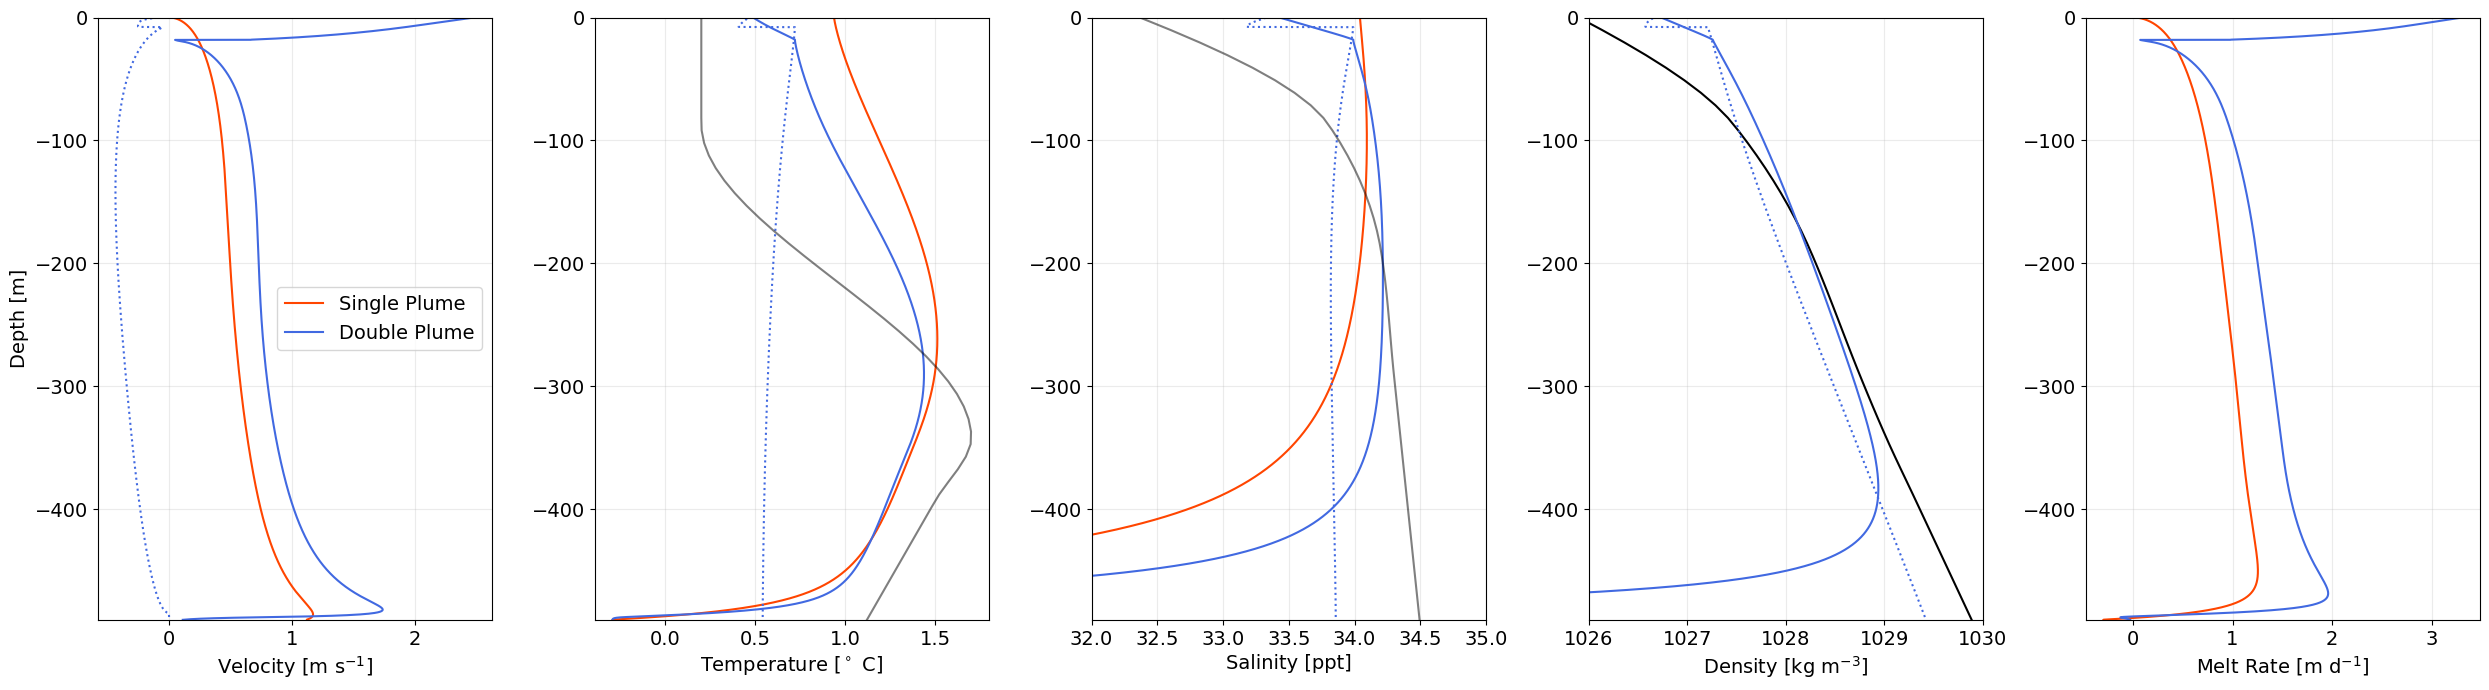

In [6]:
fig, ax = plt.subplots(1,5,figsize=(25,7))
sp_color = 'orangered'
dp_color = 'royalblue'
a_color = 'k'

ax[0].plot(u, z_sp, color = sp_color)
ax[0].plot(ui, zi_dp, color = dp_color)
ax[0].plot(uo, zo_dp, color = dp_color, linestyle = ':')

ax[1].plot(T, z_sp, color = sp_color)
ax[1].plot(Ti, zi_dp, color = dp_color)
ax[1].plot(To, zo_dp, color = dp_color, linestyle = ':')
ax[1].plot(ambient[1,:], -ambient[0,:][::-1], color = a_color, alpha = 0.5)

ax[2].plot(S, z_sp, color = sp_color)
ax[2].plot(Si, zi_dp, color = dp_color)
ax[2].plot(So, zo_dp, color = dp_color, linestyle = ':')
ax[2].set_xlim(32,35)
ax[2].plot(ambient[2,:], -ambient[0,:][::-1], color = a_color, alpha = 0.5)

ax[3].plot(rho_a, -ambient[0,:][::-1], color = a_color)
ax[3].plot(rho_i, zi_dp, color = dp_color)
ax[3].plot(rho_o, zo_dp, color = dp_color, linestyle = ':')
ax[3].set_xlim(1026,1030)

ax[4].plot(mdot_sp * sec_to_day, z_sp, color = sp_color)
ax[4].plot(mdot_dp * sec_to_day, zi_dp, color = dp_color)

for i in range(0,5):
    ax[i].set_ylim(-ambient[0,-1],0)
    ax[i].grid(alpha = 0.25)

ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('Velocity [m s$^{-1}$]')
ax[1].set_xlabel('Temperature [$^\circ$ C]')
ax[2].set_xlabel('Salinity [ppt]')
ax[3].set_xlabel('Density [kg m$^{-3}$]')
ax[4].set_xlabel('Melt Rate [m d$^{-1}$]')
ax[0].legend(['Single Plume', 'Double Plume'])
plt.tight_layout()
# plt.savefig(f"sp_dp_sol_Qsg_{p.Qsg}.png", dpi = 300)


/var/folders/b0/25x33fpn6_jcyj0hj0v0_qpw02w58x/T/ipykernel_70416/3754429086.py:3: RuntimeWarning: invalid value encountered in divide
  Co = yo[4]/yo[0]


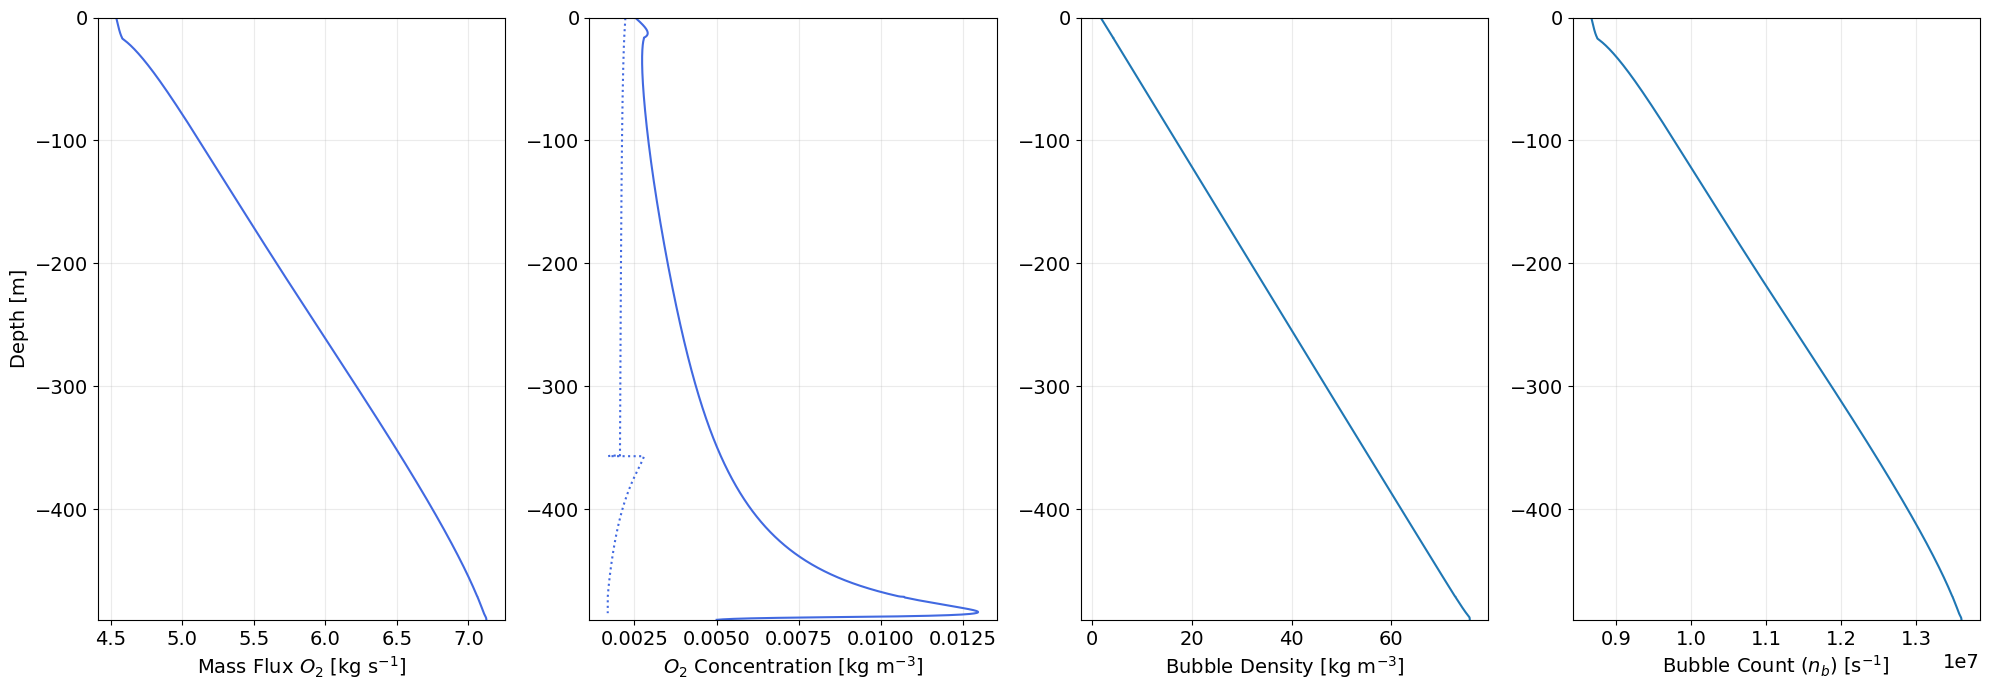

In [7]:
Mb = yi[5]
Ci = yi[6]/yi[0]
Co = yo[4]/yo[0]
Pa_interp = interp1d(ambient[0,:], ambient[-2,:])
Pa = Pa_interp(zi)
rho_b = doublePlume.gas_density(Ti,Pa, p)

nb = 6 * (Mb) / (np.pi * (0.01)**3) 
rho_a_interp = interp1d(ambient[0,:], rho_a)
rho_a_l = rho_a_interp(zi)


Cs = doublePlume.gas_SOL(rho_a_l, Ti, Si, Pa, Mb/rho_b, p)

fig, ax = plt.subplots(1,4,figsize=(20,7))

ax[0].plot(Mb, -zi[::-1], color = dp_color)

ax[1].plot(Ci, -zi[::-1], color = dp_color)
ax[1].plot(Co, -zo[::-1], color = dp_color, linestyle = ':')

ax[2].plot(rho_b, -zi[::-1])

ax[3].plot(nb, -zi[::-1])
ax[3].ticklabel_format(axis = 'x', style = 'scientific', scilimits=(0,0))

for i in range(0,4):
    ax[i].set_ylim(-ambient[0,-1],0)
    ax[i].grid(alpha = 0.25)

ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('Mass Flux $O_2$ [kg s$^{-1}$]')
ax[1].set_xlabel('$O_2$ Concentration [kg m$^{-3}$]')
ax[2].set_xlabel('Bubble Density [kg m$^{-3}$]')
ax[3].set_xlabel('Bubble Count ($n_b$) [s$^{-1}$]')
plt.tight_layout()
# plt.savefig('O2_massFlux_conc.png', dpi = 300)

/var/folders/b0/25x33fpn6_jcyj0hj0v0_qpw02w58x/T/ipykernel_70416/2520836296.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta[i] = doublePlume.gas_MT(Ti[i], rho_a_l[i], Mb[i], us[i], p)


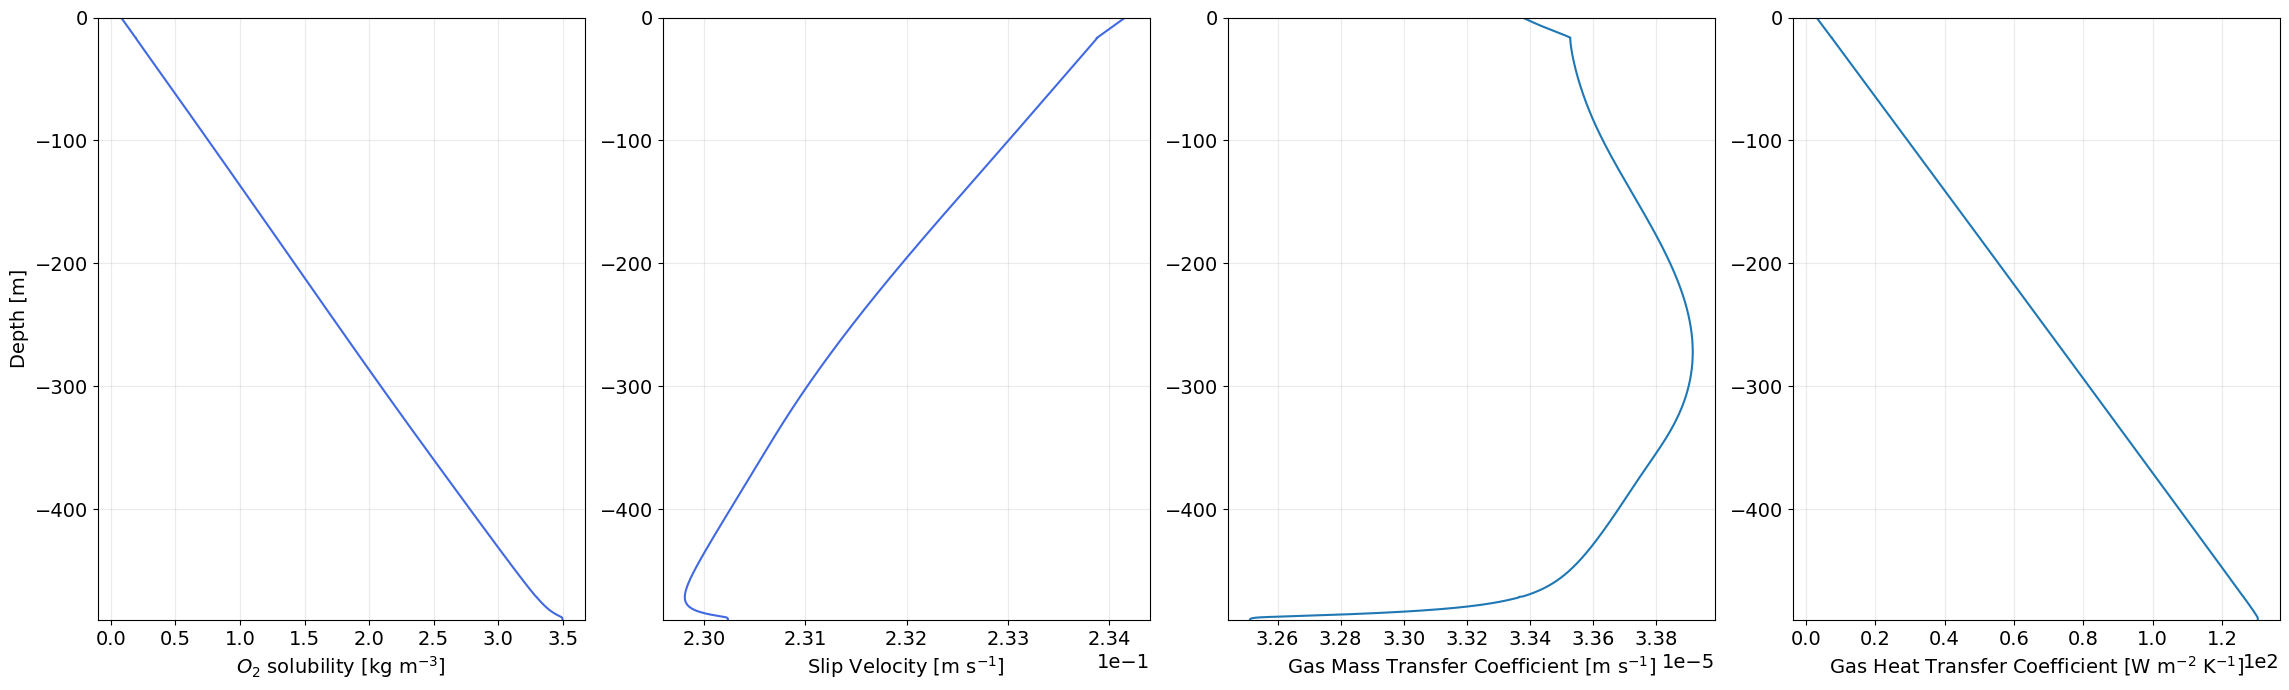

In [8]:
Cs = doublePlume.gas_SOL(rho_a_l, Ti, Si, Pa, Mb/rho_b, p)
us = np.zeros(len(zi))
beta = np.zeros(len(zi))
beta_T = np.zeros(len(zi))

for i in range(0,len(zi)):
    us[i] = doublePlume.u_slip(rho_a_l[i], rho_b[i], Ti[i], 0.01, p)
    beta[i] = doublePlume.gas_MT(Ti[i], rho_a_l[i], Mb[i], us[i], p)
    beta_T[i] = doublePlume.gas_HT(Ti[i], rho_i[i], us[i], p)

fig, ax = plt.subplots(1,4,figsize=(23,7))

ax[0].plot(Cs, -zi[::-1], color = dp_color)
ax[1].plot(us, -zi[::-1], color = dp_color)
ax[2].plot(beta, -zi[::-1])
ax[3].plot(beta_T* rho_b * c.cp_g, -zi[::-1])

ax[1].ticklabel_format(axis = 'x', style = 'scientific', scilimits=(0,0))
ax[2].ticklabel_format(axis = 'x', style = 'scientific', scilimits=(0,0))
ax[3].ticklabel_format(axis = 'x', style = 'scientific', scilimits=(0,0))

for i in range(0,4):
    ax[i].set_ylim(-ambient[0,-1],0)
    ax[i].grid(alpha = 0.25)

ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$O_2$ solubility [kg m$^{-3}$]')
ax[1].set_xlabel('Slip Velocity [m s$^{-1}$]')
ax[2].set_xlabel('Gas Mass Transfer Coefficient [m s$^{-1}$]')
ax[3].set_xlabel('Gas Heat Transfer Coefficient [W m$^{-2}$ K$^{-1}$]')
plt.tight_layout()
# plt.savefig('O2_sol_transferCoefs.png', dpi = 300)

In [68]:
Qsgs = np.array([0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,1,2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

mean_sp_mdots = np.zeros(len(Qsgs))
mean_dp_mdots = np.zeros(len(Qsgs))
max_sp_mdots = np.zeros(len(Qsgs))
max_dp_mdots = np.zeros(len(Qsgs))

mean_sp_u = np.zeros(len(Qsgs))
mean_dp_u = np.zeros(len(Qsgs))
max_sp_u = np.zeros(len(Qsgs))
max_dp_u = np.zeros(len(Qsgs))

jps = np.zeros(len(Qsgs))
i = 0

for Qsg in Qsgs:
    p.R = 2.5 # [m]
    p.C0 = 0.05 # [kg/m^3]
    p.S0 = 0.01 # [psu]
    p.Qsg = Qsg#1e-2
    p.Usg = 2 * p.Qsg / (np.pi * p.R**2)
    p.modelType = 'single_plume'
    rho_g = ambient[3,0] * c.M_gas[0][0][0] / (c.Ru * c.T0) # [kg/m^3]

    cmap = cm.haline(np.linspace(0,1,len(jps)))
    i_peels = []
    phi = 0.1 # Fraction of volume by air in ice
    Qg = phi * p.Qsg 
    mb0 = Qg * rho_g # [kg/s]
    p.mb0 = mb0
    singlePlume = dP(ambient, p)
    y, z, yo, zo, jp, i_peel = dP.returnResults(singlePlume)
    mdot_sp = singlePlume.melting(y, z, p)
    Sb_sp = singlePlume.boundary_salinity(y, mdot_sp, p)
    Tb_sp = singlePlume.boundary_temperature(Sb_sp, z, p)

    p.modelType = 'double_plume'
    doublePlume = dP(ambient, p)
    yi, zi, yo, zo, jp, i_peel = dP.returnResults(doublePlume)
    mdot_dp = doublePlume.melting(yi, zi, p)
    Sb_dp = doublePlume.boundary_salinity(yi, mdot_dp, p)
    Tb_dp = doublePlume.boundary_temperature(Sb_dp, zi, p)

    mean_sp_mdots[i] = np.mean(mdot_sp)
    mean_dp_mdots[i] = np.mean(mdot_dp)
    max_sp_mdots[i] = np.max(mdot_sp)
    max_dp_mdots[i] = np.max(mdot_dp)

    mean_sp_u[i] = np.mean(y[1]/y[0])
    mean_dp_u[i] = np.mean(yi[1]/yi[0])
    max_sp_u[i] = np.max(y[1]/y[0])
    max_dp_u[i] = np.max(yi[1]/yi[0])

    jps[i] = jp

    i = i + 1


/Users/mmamer3/anaconda3/lib/python3.10/site-packages/gsw/_wrapped_ufuncs.py:5578: RuntimeWarning: invalid value encountered in rho_t_exact
  return _gsw_ufuncs.rho_t_exact(SA, t, p)


Q_g = 0.009408903127328672
=== Plume Initial Conditions ===
Qi=0.109 m^3/s, Ji=0.001 m^4/s^2, Hi=128822890.201 m^3°C/s, Bi=0.001 m^3/s psu, Ci=0.005470 kg/s
ui=0.011 m/s, bi=2.500 m,               Ti=-0.293 °C, Si=0.010 m^3/s psu, Ci=0.050000 kg/m^3
tambient, sambient: 1.12,34.495
No momentum. ui = 0.011144299360625078, mom = 0.0012192855691685802
No momentum. ui = 0.011355438396623509, mom = 0.001343612249485674
No momentum. ui = 0.011144299360625078, mom = 0.0012192855691685802
No momentum. ui = 0.011355438396623509, mom = 0.001343612249485674
Discrete peel 1
 Height: 0.0 m
Initial conditions for next peel:
Qi: 0.005470445156366439, ui: 1.0395561516640281
No momentum. ui = 0.04806048566177531, mom = 27.93123509657407
No momentum. ui = 0.04806048566177531, mom = 27.93123509657407
Discrete peel 2
 Height: 482.58494092021357 m
Initial conditions for next peel:
Qi: 29.05841952278593, ui: 0.8589263938952353
Initial Conditions for outer plume
Qo, uo, To, So, Co: -40.09500497248409, [0.0435

/Users/mmamer3/Documents/plume/doublePlume_V3.py:456: RuntimeWarning: invalid value encountered in scalar power
  bo = (2 * yo[0]/(uo * np.pi) + bi**2)**(1/2)                                   # outer radius


outer plume lost momentum, y[1]: 0.0004290715490098587
outer plume lost momentum, y[1]: 0.0004290715490098587
No momentum. ui = 0.011144299360625078, mom = 0.0012192855691685802
No momentum. ui = 0.011355438396623509, mom = 0.001343612249485674
No momentum. ui = 0.011144299360625078, mom = 0.0012192855691685802
No momentum. ui = 0.011355438396623509, mom = 0.001343612249485674
Discrete peel 1
 Height: 0.0 m
Initial conditions for next peel:
Qi: 0.005470445156366439, ui: 1.0395561516640281
No momentum. ui = 0.04806048566177531, mom = 27.93123509657407
No momentum. ui = 0.04806048566177531, mom = 27.93123509657407
Discrete peel 2
 Height: 482.58494092021357 m
Initial conditions for next peel:
Qi: 29.05841952278593, ui: 0.8589263938952353
Initial Conditions for outer plume
Qo, uo, To, So, Co: -40.09500497248409, [0.04352507], 0.5356484506139064, 33.54645445790889, 0.00301511415146269
z0: 490.0
      - Top outer plume 490.0 - 482.58494092021357
 Initial conditions are: 
outer plume lost mo

/Users/mmamer3/Documents/plume/doublePlume_V3.py:1356: RuntimeWarning: invalid value encountered in scalar power
  b = (2 * y[0]/(u * np.pi))**(1/2)                                      # inner radius


Q_g = 0.1881780625465734
=== Plume Initial Conditions ===
Qi=2.188 m^3/s, Ji=0.488 m^4/s^2, Hi=2576457804.018 m^3°C/s, Bi=0.022 m^3/s psu, Ci=0.109409 kg/s
ui=0.223 m/s, bi=2.500 m,               Ti=-0.293 °C, Si=0.010 m^3/s psu, Ci=0.050000 kg/m^3
tambient, sambient: 1.12,34.495
Initial Conditions for outer plume
Qo, uo, To, So, Co: -3312.9360249095544, [0.10822889], 0.5740238480505901, 33.6962211160396, 0.007778418672157139
z0: 490.0
      - Top outer plume 490.0 - 0.0
 Initial conditions are: 
outer plume lost momentum, y[1]: 0.0004445595879197316
outer plume lost momentum, y[1]: 0.00044455958791973153
Initial Conditions for outer plume
Qo, uo, To, So, Co: -3312.9360249095544, [0.10822889], 0.5740238480505901, 33.6962211160396, 0.007778418672157139
z0: 490.0
      - Top outer plume 490.0 - 0.0
 Initial conditions are: 
outer plume lost momentum, y[1]: 0.0004445595879197316
outer plume lost momentum, y[1]: 0.00044455958791973153
Percent Error = 0.0
Q_g = 0.2822670938198601
=== Plume 

/Users/mmamer3/Documents/plume/doublePlume_V3.py:1048: RuntimeWarning: invalid value encountered in sqrt
  bo = (2 * Qo/(np.pi * uo) + bi**2)**(1/2)
/Users/mmamer3/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Initial Conditions for outer plume
Qo, uo, To, So, Co: -3833.8463993473806, [0.11163865], 0.5728562711768703, 33.68859509572278, 0.008942052622751991
z0: 490.0
      - Top outer plume 490.0 - 0.0
 Initial conditions are: 
outer plume lost momentum, y[1]: 0.0004870985804053387
outer plume lost momentum, y[1]: 0.0004870985804053386
Percent Error = 0.0
Q_g = 0.3763561250931468
=== Plume Initial Conditions ===
Qi=4.376 m^3/s, Ji=1.951 m^4/s^2, Hi=5152915608.036 m^3°C/s, Bi=0.044 m^3/s psu, Ci=0.218818 kg/s
ui=0.446 m/s, bi=2.500 m,               Ti=-0.293 °C, Si=0.010 m^3/s psu, Ci=0.050000 kg/m^3
tambient, sambient: 1.12,34.495
Initial Conditions for outer plume
Qo, uo, To, So, Co: -4250.266213187495, [0.11405479], 0.5722414537971562, 33.6823131719193, 0.009870555413317295
z0: 490.0
      - Top outer plume 490.0 - 0.0
 Initial conditions are: 
outer plume lost momentum, y[1]: 0.0004889496597752872
outer plume lost momentum, y[1]: 0.0004889496597752873
Initial Conditions for outer plume
Qo

In [40]:
len(Qsgs)

35

In [31]:
Qsgs[i]

7.648275862068965

/var/folders/b0/25x33fpn6_jcyj0hj0v0_qpw02w58x/T/ipykernel_49100/594706662.py:14: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0,32)


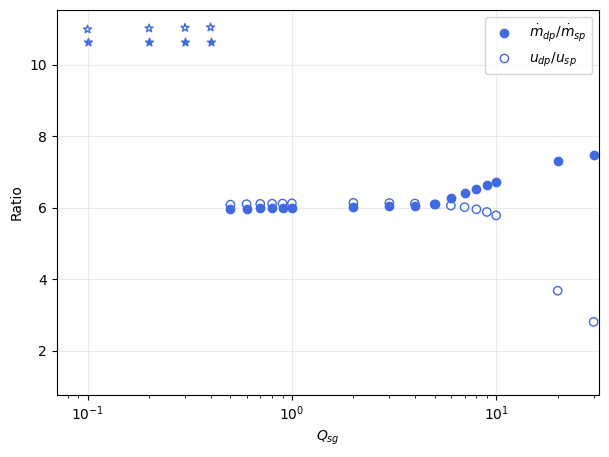

In [73]:
fig, ax = plt.subplots(1,figsize=(7,5))
noPeels = np.where(jps == 0)[0]
peels = np.where(jps > 0)[0]
ax.scatter(Qsgs[noPeels], max_dp_mdots[noPeels]/max_sp_mdots[noPeels], color = 'royalblue', zorder = 2)
ax.scatter(Qsgs[noPeels], max_dp_u[noPeels]/max_sp_u[noPeels], color = 'royalblue', facecolor = 'none', zorder = 2)

ax.scatter(Qsgs[peels], max_dp_mdots[peels]/max_sp_mdots[peels], color = 'royalblue', marker="*")
ax.scatter(Qsgs[peels], max_dp_u[peels]/max_sp_u[peels], color = 'royalblue', facecolor = 'none', marker = '*')

ax.set_xlabel('$Q_{sg}$')
ax.set_ylabel('Ratio')
ax.grid(alpha = 0.25, zorder = 1)
ax.set_xscale('log'); 
ax.set_xlim(0,32)
ax.legend(['$\dot{m}_{dp}/\dot{m}_{sp}$', '$u_{dp}/u_{sp}$'])

plt.savefig('singlePlume_doublePlume_ratio.png', dpi = 300)

Q_g = 0.000940890312732867
=== Plume Initial Conditions ===
Qi=0.011 m^3/s, Ji=0.000 m^4/s^2, Hi=12882289.020 m^3°C/s, Bi=0.000 m^3/s psu, Ci=0.000055 kg/s
ui=0.001 m/s, bi=2.500 m,               Ti=-0.293 °C, Si=0.010 m^3/s psu, Ci=0.005000 kg/m^3
tambient, sambient: 1.12,34.495
No momentum. ui = 0.0011144299360625078, mom = 1.21928556916858e-05
No momentum. ui = 0.0011060870736000641, mom = 1.3164400750967343e-05
No momentum. ui = 0.0011144299360625078, mom = 1.21928556916858e-05
No momentum. ui = 0.0011060870736000644, mom = 1.3164400750967345e-05
Discrete peel 1
 Height: 0.0 m
Initial conditions for next peel:
Qi: 0.0005470445156366438, ui: 0.4543225767913307
No momentum. ui = 0.04945257512359814, mom = 5.436096396650251
No momentum. ui = 0.04945257512359814, mom = 5.436096396650251
Discrete peel 2
 Height: 320.2688495564316 m
Initial conditions for next peel:
Qi: 5.496272320565386, ui: 0.19670571440491916
No momentum. ui = 0.04839074213430906, mom = 2.6547470718985355
No momentum.

/Users/mmamer3/Documents/plume/doublePlume_V3.py:455: RuntimeWarning: invalid value encountered in scalar power
  bo = (2 * yo[0]/(uo * np.pi) + bi**2)**(1/2)                                   # outer radius


outer plume lost momentum, y[1]: 0.0004910845560807445
outer plume lost momentum, y[1]: 0.0004910845560807445
outer plume lost momentum, y[1]: 0.0004432782073699618
outer plume lost momentum, y[1]: 0.00044327820736996177
outer plume lost momentum, y[1]: 0.0004823445023582016
outer plume lost momentum, y[1]: 0.0004823445023582016
No momentum. ui = 0.0011144299360625078, mom = 1.21928556916858e-05
No momentum. ui = 0.0011060870736000641, mom = 1.3164400750967343e-05
No momentum. ui = 0.0011144299360625078, mom = 1.21928556916858e-05
No momentum. ui = 0.0011060870736000644, mom = 1.3164400750967345e-05
Discrete peel 1
 Height: 0.0 m
Initial conditions for next peel:
Qi: 0.0005470445156366438, ui: 0.4543225767913307
No momentum. ui = 0.04945257512359814, mom = 5.436096396650251
No momentum. ui = 0.04945257512359814, mom = 5.436096396650251
Discrete peel 2
 Height: 320.2688495564316 m
Initial conditions for next peel:
Qi: 5.496272320565386, ui: 0.19670571440491916
No momentum. ui = 0.048390

/var/folders/b0/25x33fpn6_jcyj0hj0v0_qpw02w58x/T/ipykernel_51769/3979570782.py:30: RuntimeWarning: invalid value encountered in divide
  uo = yo[1]/yo[0]


No momentum. ui = 0.04849766176731933, mom = 28.353599641493886
No momentum. ui = 0.04849766176731933, mom = 28.353599641493886
Discrete peel 2
 Height: 482.61038627847313 m
Initial conditions for next peel:
Qi: 29.23192439413676, ui: 0.8598805671089772
Initial Conditions for outer plume
Qo, uo, To, So, Co: -40.265023582850304, [0.04358394], 0.5363206451350297, 33.548270486970495, 0.0030160032335175314
z0: 490.0
      - Top outer plume 490.0 - 482.61038627847313
 Initial conditions are: 
outer plume lost momentum, y[1]: 0.0004486110441149048
outer plume lost momentum, y[1]: 0.0004486110441149048
No momentum. ui = 0.011144299360625078, mom = 0.0012192855691685802
No momentum. ui = 0.011357030056736906, mom = 0.0013445842984162295
No momentum. ui = 0.011144299360625078, mom = 0.0012192855691685802
No momentum. ui = 0.011357030056736904, mom = 0.0013445842984162295
Discrete peel 1
 Height: 0.0 m
Initial conditions for next peel:
Qi: 0.005470445156366439, ui: 1.0395561516640281
No momentum

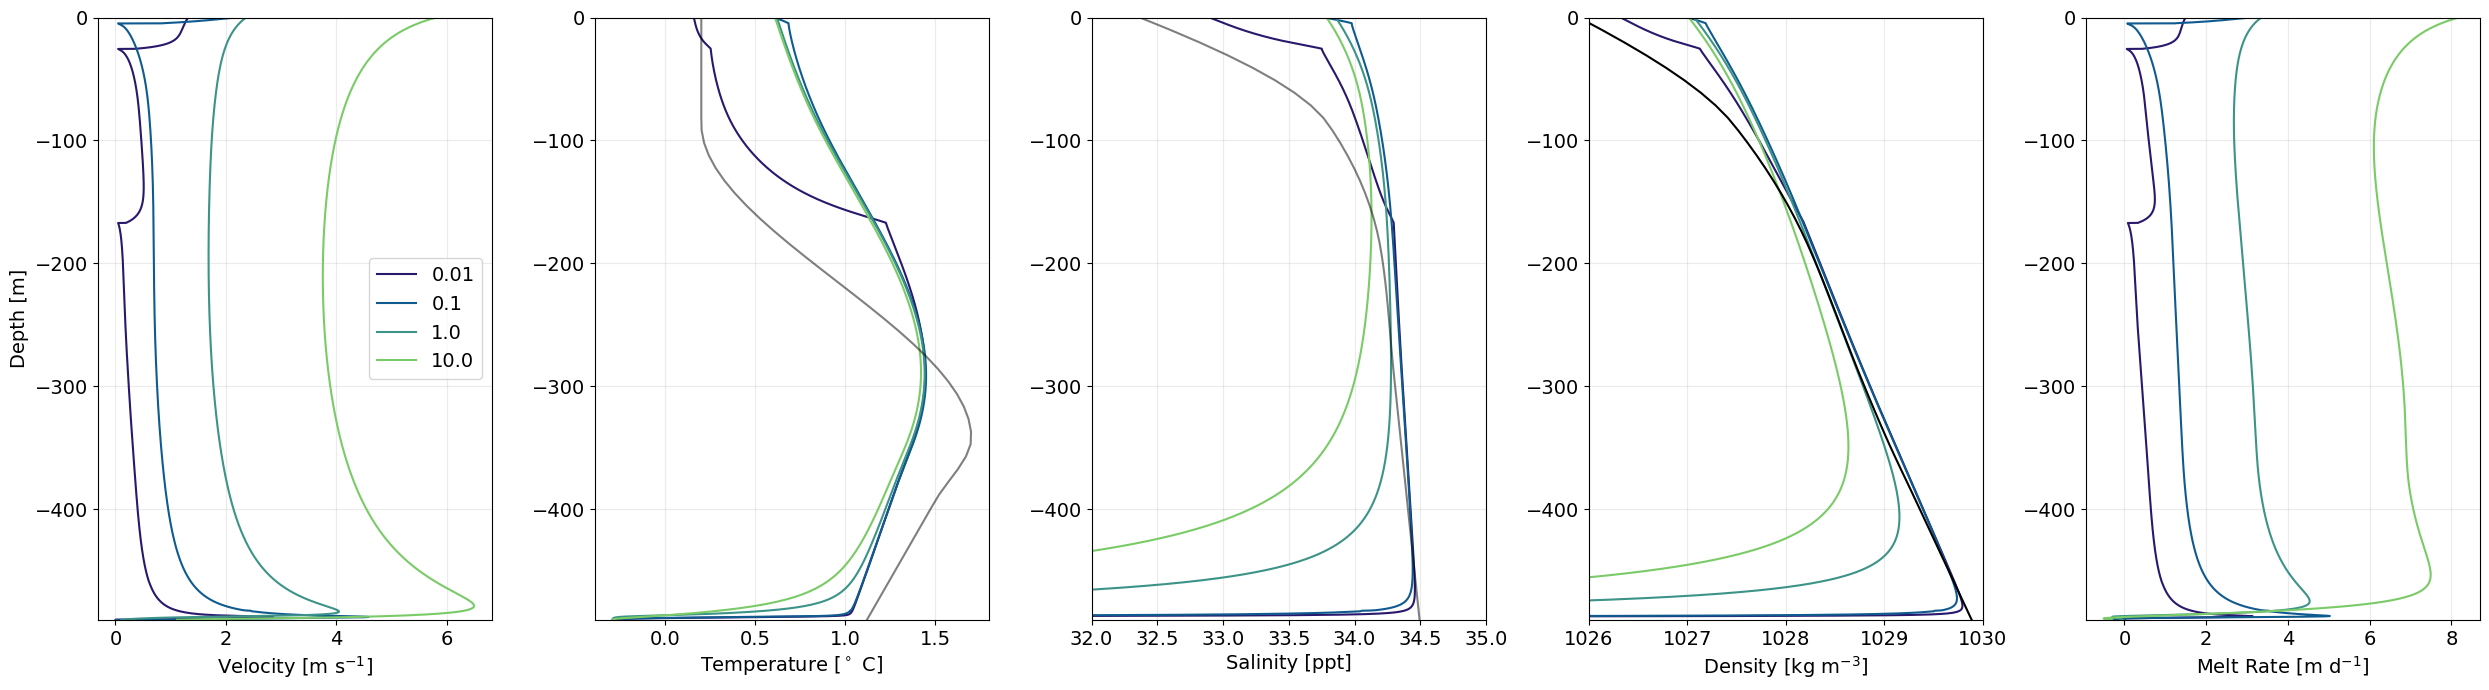

In [51]:
fig, ax = plt.subplots(1,5,figsize=(25,7))
sp_color = 'orangered'
dp_color = 'royalblue'
a_color = 'k'
cmap = cm.haline(np.linspace(0,1,5))
jps = np.zeros(4)
i = 0
for Qsg in np.array([0.01, 0.1, 1, 10]):
    p.R = 2.5 # [m]
    p.C0 = 0.005 # [kg/m^3]
    p.S0 = 0.01 # [psu]
    p.Qsg = Qsg#1e-2
    rho_g = ambient[3,0] * c.M_gas[0][0][0] / (c.Ru * c.T0) # [kg/m^3]

    phi = 0.1 # Fraction of volume by air in ice
    Qg = phi * p.Qsg 
    mb0 = Qg * rho_g # [kg/s]
    p.mb0 = mb0
    p.modelType = 'double_plume'
    doublePlume = dP(ambient, p)
    yi, zi, yo, zo, jp, i_peel = dP.returnResults(doublePlume)
    mdot_dp = doublePlume.melting(yi, zi, p)
    Sb_dp = doublePlume.boundary_salinity(yi, mdot_dp, p)
    Tb_dp = doublePlume.boundary_temperature(Sb_dp, zi, p)

    ui = yi[1]/yi[0]
    Ti = yi[2]/(yi[0] * c.cp * p.rho_r) - c.T0
    Si = yi[4]/yi[0]

    uo = yo[1]/yo[0]

    Pa_interp = interp1d(ambient[0,:][::-1], ambient[-2,:])
    Pa_i = Pa_interp(zi[::-1])
    rho_i = gsw.density.rho_t_exact(Si, Ti, Pa_i/10**4)
    rho_o = gsw.density.rho_t_exact(So, To, Pa_o/10**4)
    rho_a = gsw.density.rho_t_exact(ambient[2,:], ambient[1,:], ambient[-2,:]/10**4)

    ax[0].plot(ui, -zi[::-1], color = cmap[i], label = Qsg)

    ax[1].plot(Ti, -zi[::-1], color = cmap[i])
    #ax[1].plot(To, zo_dp, color = dp_color, linestyle = ':')

    ax[2].plot(Si, -zi[::-1], color = cmap[i])
    #ax[2].plot(So, zo_dp, color = dp_color, linestyle = ':')
    ax[2].set_xlim(32,35)

    ax[3].plot(rho_i, -zi[::-1], color = cmap[i])
    #ax[3].plot(rho_o, zo_dp, color = dp_color, linestyle = ':')
    ax[3].set_xlim(1026,1030)

    ax[4].plot(mdot_dp * sec_to_day, -zi[::-1], color = cmap[i])
    jps[i] = jp 
    i = i + 1

for i in range(0,5):
    ax[i].set_ylim(-ambient[0,-1],0)
    ax[i].grid(alpha = 0.25)

ax[1].plot(ambient[1,:], -ambient[0,:][::-1], color = a_color, alpha = 0.5)
ax[2].plot(ambient[2,:], -ambient[0,:][::-1], color = a_color, alpha = 0.5)
ax[3].plot(rho_a, -ambient[0,:][::-1], color = a_color)

ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('Velocity [m s$^{-1}$]')
ax[1].set_xlabel('Temperature [$^\circ$ C]')
ax[2].set_xlabel('Salinity [ppt]')
ax[3].set_xlabel('Density [kg m$^{-3}$]')
ax[4].set_xlabel('Melt Rate [m d$^{-1}$]')
ax[0].legend()
plt.tight_layout()
plt.savefig('multiple_Qsg_profiles.png', dpi = 300)